<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/02_Airbnb_Berlin_EDA1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install missingno
# !pip install geopy

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import missingno as msno
sns.set()
plt.style.use('ggplot')
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_EDA = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA.pkl')

In [ ]:
df = df_EDA.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        18888 non-null  float64
 1   Bathrooms              23507 non-null  float64
 2   Checkin Rating         18870 non-null  float64
 3   Cleanliness Rating     18892 non-null  float64
 4   Communication Rating   18886 non-null  float64
 5   Host Response Rate     13046 non-null  float64
 6   Latitude               23536 non-null  float64
 7   Location Rating        18871 non-null  float64
 8   Longitude              23536 non-null  float64
 9   Overall Rating         18914 non-null  float64
 10  Price                  23536 non-null  float64
 11  Square Feet            425 non-null    float64
 12  Value Rating           18868 non-null  float64
 13  review_date            19380 non-null  object 
 14  Comments               19378 non-null  object 
 15  Ho

## Defines data columns Lists

In [ ]:
numerical_columns = ['Price','Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time']
date_columns = ['review_date','Host Since']
non_categorical_columns = numerical_columns + rating_columns + boolean_columns

# EDA - Explenatory Data Analysis

In [ ]:
df.head(2)

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,review_date,Comments,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Property Type Reduced,Postal Code Reduced
0,10.0,1.0,10.0,10.0,10.0,50.0,52.54851,9.0,13.40455,100.0,17.0,NaN,10.0,07-04-18,I really enjoyed staying at Micha and Nadja's ...,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,2,1.0,1.0,1,2,7,Apartment,10
1,9.0,1.0,9.0,9.0,9.0,50.0,52.53500,10.0,13.41758,92.0,90.0,720.0,9.0,06-20-09,"excellent stay, i would highly recommend it. a...",10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,4,1.0,2.0,2,62,144,Apartment,10


## Data Protocol

In [ ]:
#Type of data
df.dtypes.to_excel ("df_datatype.xlsx", sheet_name='data_types')

#Maximum points
df[non_categorical_columns].max().to_excel("df_max.xlsx", sheet_name='max')

#Minimum points
df[non_categorical_columns].max().to_excel("df_max.xlsx", sheet_name='min')

#Isnull values
df.isnull().to_excel("df_isnull.xlsx", sheet_name='isnull')

#unique values
df.nunique().to_excel("df_nunique.xlsx", sheet_name='nunique')

# Categorical values
df[categorical_columns].describe().to_excel("df_categorical.xlsx", sheet_name='categorical')

## Descriptive statistics
   

In [ ]:
df.shape

(23536, 33)

In [ ]:
df[numerical_columns].describe()

,Price,Accomodates,Bathrooms,Bedrooms,Beds,Guests Included,Min Nights,Reviews
count,23536.000000,23536.000000,23507.000000,23516.000000,23501.000000,23536.000000,23536.000000,23536.000000
mean,69.612424,2.671737,1.095971,1.161720,1.641802,1.346151,6.897774,19.238826
std,216.660408,1.567812,0.346150,0.660736,1.228642,0.856297,24.879032,40.360483
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,32.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000
50%,49.000000,2.000000,1.000000,1.000000,1.000000,1.000000,3.000000,5.000000
75%,75.000000,3.000000,1.000000,1.000000,2.000000,1.000000,4.000000,17.000000
max,9000.000000,16.000000,8.500000,10.000000,22.000000,16.000000,1000.000000,545.000000


In [ ]:
df[rating_columns].describe()

,Value Rating,Location Rating,Cleanliness Rating,Checkin Rating,Accuracy Rating,Communication Rating,Host Response Rate,Overall Rating
count,18868.000000,18871.000000,18892.000000,18870.000000,18888.000000,18886.000000,13046.000000,18914.000000
mean,9.417638,9.550315,9.334904,9.728829,9.679850,9.746479,91.842174,94.564344
std,0.840456,0.748713,1.031248,0.695275,0.737798,0.679600,19.447852,7.599949
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,20.000000
25%,9.000000,9.000000,9.000000,10.000000,10.000000,10.000000,95.000000,92.000000
50%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,97.000000
75%,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000,100.000000


In [ ]:
df[boolean_columns].describe()

,Is Superhost,Is Exact Location,Instant Bookable
count,23536,23536,23536
unique,2,2,2
top,False,True,False
freq,19969,17649,15658


In [ ]:
df[categorical_columns].describe()

,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time
count,23536,23536,23536,23536,13046
unique,3,15,12,8,4
top,Private room,Apartment,Friedrichshain-Kreuzberg,10,within an hour
freq,11694,20935,5726,14667,6816


In [ ]:
# df[['Host Since Year', 'Host Since Month', 'Host Since Day']].describe()

Several rows with unusually high values can be identified and may in some cases be dropped at a certain threshold

The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

In [ ]:
df[['Beds', 'Min Nights', 'Reviews', 'Price']].describe().loc[['max']].T

,max
Beds,22.0
Min Nights,1000.0
Reviews,545.0
Price,9000.0


## Target Value

In [ ]:
df[['Price']].describe()

,Price
count,23536.000000
mean,69.612424
std,216.660408
min,0.000000
25%,32.000000
50%,49.000000
75%,75.000000
max,9000.000000


The description of price shows that 75% of the room only charged within 70€. But we can find the maximized price is extremely large - up to 9000€.

### Distribution of Price

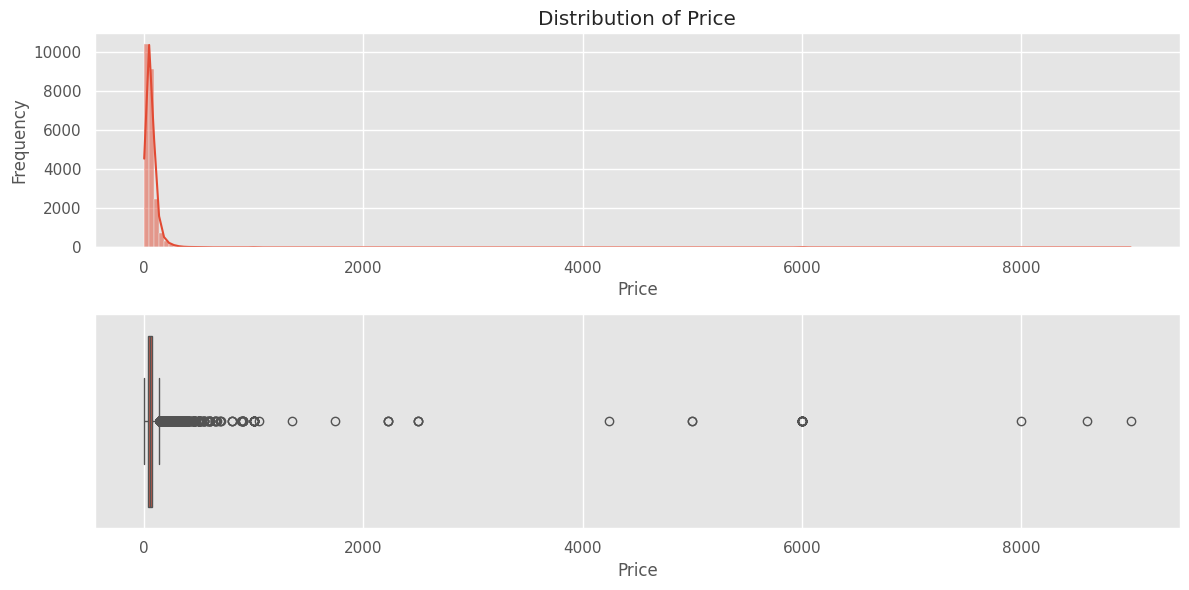

In [ ]:
def target_value_distributions(df):
  plt.figure(figsize=(12, 6))
  plt.subplot(2, 1, 1)
  sns.histplot(df['Price'], bins=200, kde=True)
  plt.title("Distribution of Price")
  plt.xlabel("Price")
  plt.ylabel("Frequency")

  plt.subplot(2, 1, 2)
  sns.boxplot(df['Price'], orient='h')
  plt.xlabel("Price")

  plt.tight_layout()
  plt.show()

# Distribution of Price before dropping extream outlier values
target_value_distributions(df)

In [ ]:
# df = df[(df['Price'] <= 600) & (df['Price'] > 0)]
df['Price'].describe()

,Price
count,23536.000000
mean,69.612424
std,216.660408
min,0.000000
25%,32.000000
50%,49.000000
75%,75.000000
max,9000.000000


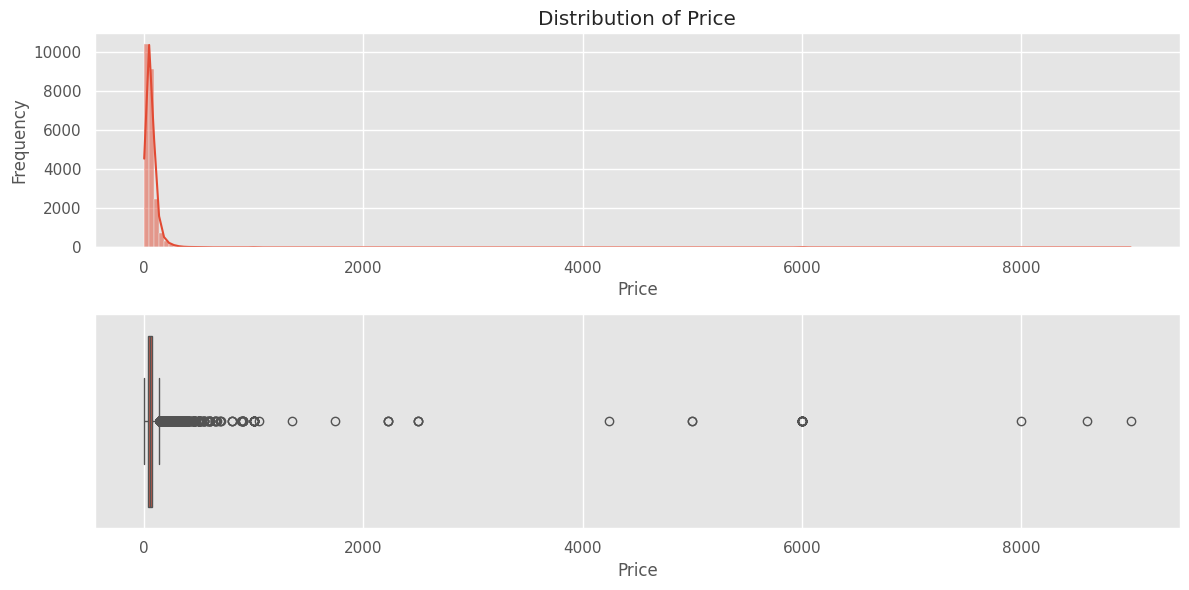

In [ ]:
# Distribution of Price
target_value_distributions(df)

### Location vs Price

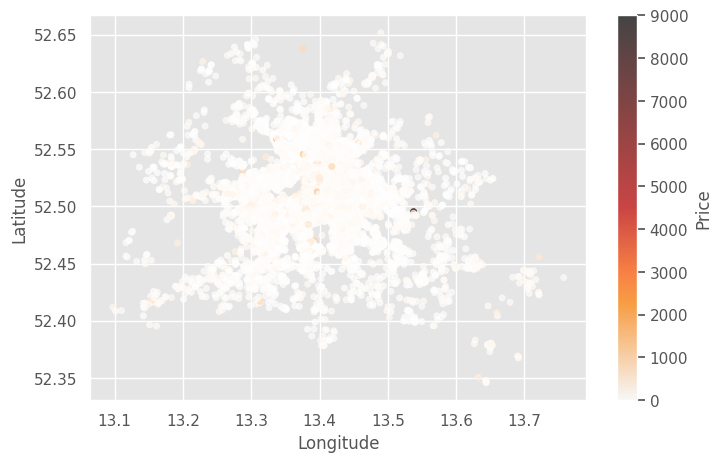

In [ ]:
df.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.7, figsize=(8,5),
        c="Price", cmap="gist_heat_r", colorbar=True, sharex=False);

In [ ]:
df.columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'review_date', 'Comments', 'Host Since',
       'Host Response Time', 'Is Superhost', 'neighbourhood',
       'Neighborhood Group', 'Postal Code', 'Is Exact Location',
       'Property Type', 'Room Type', 'Instant Bookable', 'Accomodates',
       'Bedrooms', 'Beds', 'Guests Included', 'Min Nights', 'Reviews',
       'Property Type Reduced', 'Postal Code Reduced'],
      dtype='object')

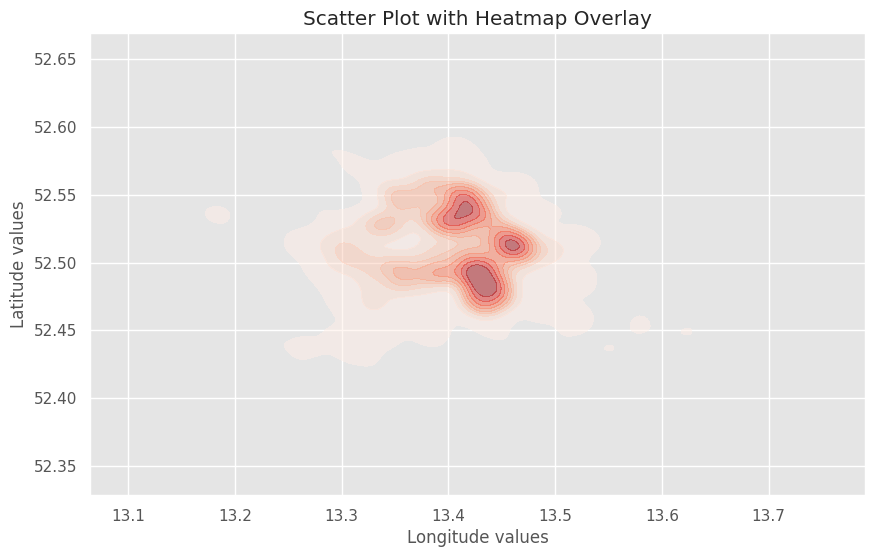

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot the heatmap using KDE (Kernel Density Estimation)
sns.kdeplot(x=df["Longitude"], y=df["Latitude"], cmap="Reds", fill=True, alpha=0.5)

# Overlay scatter plot
# sns.scatterplot(x=df["Longitude"], y=df["Latitude"], color="blue", alpha=0.5, cmap="viridis")
# sns.scatterplot(data=df, x="Longitude", y="Latitude", color="blue", alpha=0.5, cmap="viridis")
# sns.scatterplot(data=df, x="Longitude", y="Latitude", color="blue", alpha=0.5, size='Price' )

# Labels and title
plt.xlabel("Longitude values")
plt.ylabel("Latitude values")
plt.title("Scatter Plot with Heatmap Overlay")

# Show the plot
plt.show()


## Missing values

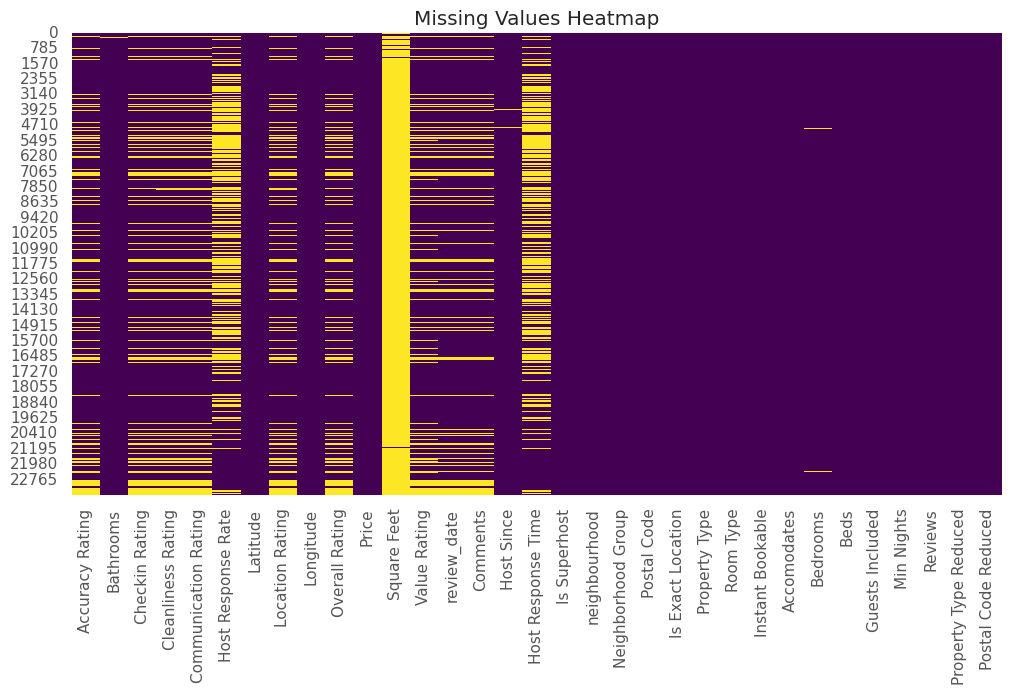

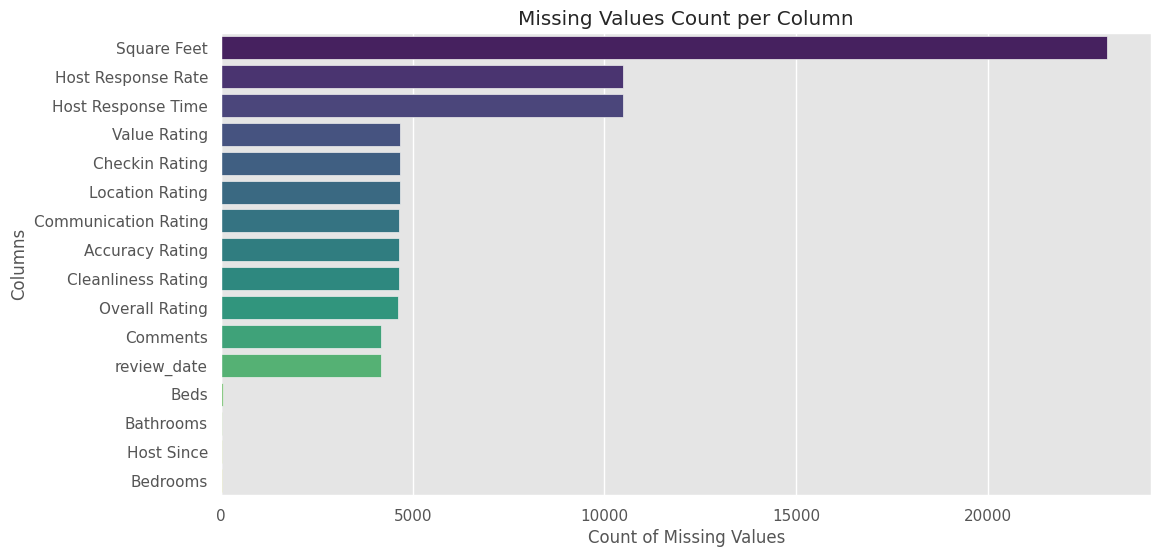


Missing Values:
Square Feet             23111
Host Response Rate      10490
Host Response Time      10490
Value Rating             4668
Checkin Rating           4666
Location Rating          4665
Communication Rating     4650
Accuracy Rating          4648
Cleanliness Rating       4644
Overall Rating           4622
Comments                 4158
review_date              4156
Beds                       35
Bathrooms                  29
Host Since                 21
Bedrooms                   20
dtype: int64


In [ ]:
# Check for missing values
missing_values = df.isnull().sum()

# Visualizing missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# Display missing values as a bar chart
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.values, y=missing_values.index, palette="viridis")
plt.xlabel("Count of Missing Values")
plt.ylabel("Columns")
plt.title("Missing Values Count per Column")
plt.show()


print("\nMissing Values:")
print(missing_values)

## Dummies

In [ ]:
def plot_counts_for_columns(df, columns_names, rows=1, cols=3, figsize_=(20, 6)):
  i = 1
  plt.figure(figsize=figsize_)
  plt.subplots_adjust(hspace = 0.5)
  for col in columns_names:
    plt.subplot(rows, cols, i)
    plt.title(f"'{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    sns.countplot(data=df, x=col, palette="viridis")
    i = i + 1

  plt.tight_layout()
  plt.show()
  print (i)

In [ ]:
boolean_columns

['Is Superhost', 'Is Exact Location', 'Instant Bookable']

In [ ]:
df['Is Superhost'] = df['Is Superhost'].astype(bool)
df[boolean_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Is Superhost       23536 non-null  bool 
 1   Is Exact Location  23536 non-null  bool 
 2   Instant Bookable   23536 non-null  bool 
dtypes: bool(3)
memory usage: 69.1 KB


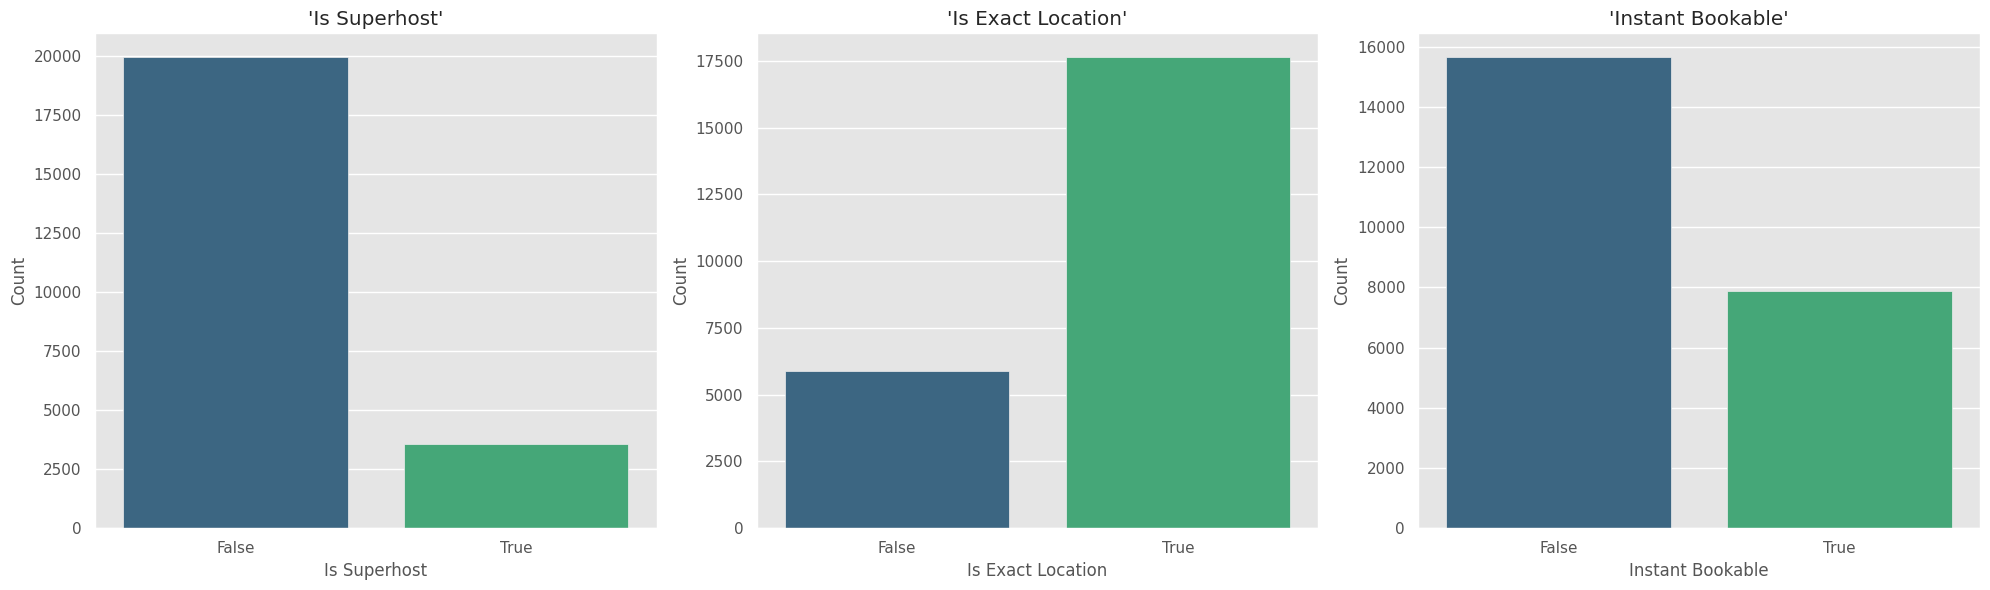

4


In [ ]:
plot_counts_for_columns(df, boolean_columns)

## Categorial

In [ ]:
df[categorical_columns].describe().T

,count,unique,top,freq
Room Type,23536,3,Private room,11694
Property Type Reduced,23536,15,Apartment,20935
Neighborhood Group,23536,12,Friedrichshain-Kreuzberg,5726
Postal Code Reduced,23536,8,10,14667
Host Response Time,13046,4,within an hour,6816


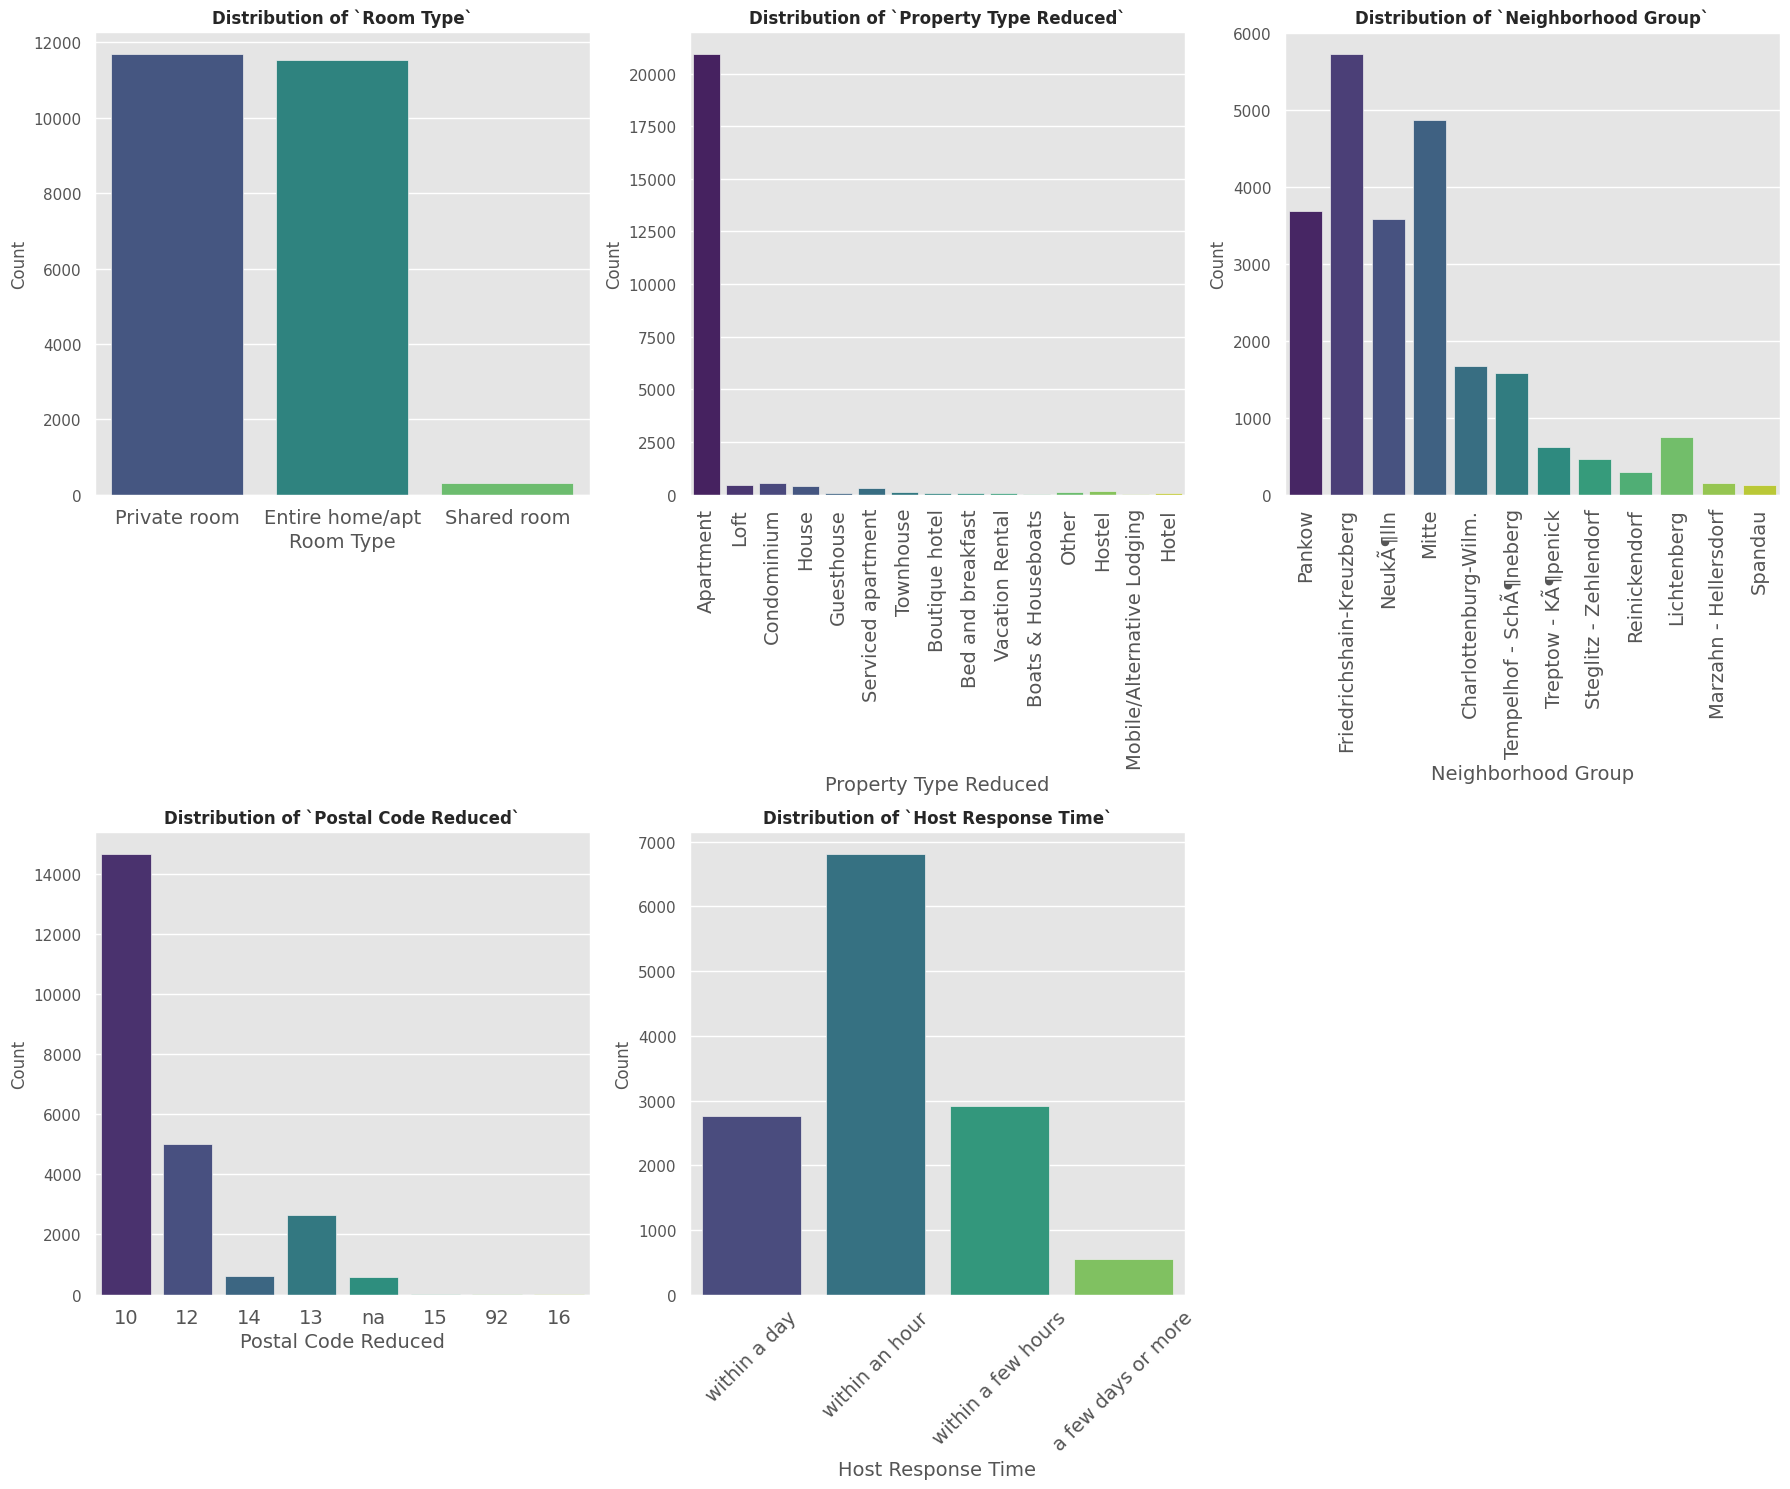

In [ ]:
xticks_map = {'Room Type':0, 'Property Type Reduced':90, 'Neighborhood Group':90, 'Neighbourhood Grouped':90, 'Postal Code Reduced':0, 'Host Response Time':45}
i = 1
plt.figure(figsize=(18, 15))
plt.subplots_adjust(hspace = 0.5)
for col in categorical_columns:
  plt.subplot(2, 3, i)
  plt.title(f"Distribution of `{col}`", fontsize=12, fontweight="bold")
  plt.xlabel(col, fontsize=14)
  plt.xticks(rotation=xticks_map.get(col, 0), fontsize=14)
  plt.ylabel("Count")
  sns.countplot(data=df, x=col, palette="viridis")
  i = i + 1

plt.tight_layout()
plt.show()

In [ ]:
# df = df_EDA.copy()

In [ ]:
# df['Host Since Year'] = df['Host Since Year'].astype('str').apply(lambda x: (x.split('.')[0]))
# df['Host Since Year'] = df['Host Since Year'].apply(lambda x: None if x == 'nan' else x).astype('category')
# df['Host Since Month'] = df['Host Since Month'].astype('str').apply(lambda x: x.split('.')[0])
# df['Host Since Month'] = df['Host Since Month'].apply(lambda x: None if x == 'nan' else x).astype('category')
# df['Host Since Day'] = df['Host Since Day'].astype('str').apply(lambda x: x.split('.')[0])
# df['Host Since Day'] = df['Host Since Day'].apply(lambda x: None if x == 'nan' else x).astype('category')

In [ ]:
# df['Host Since Year'].info()

In [ ]:
# df['Host Since Year'].isna().sum()

In [ ]:
# df['Host Since Month'].value_counts().index.sort_values()
# df['Host Since Month'].value_counts().index.sort_values( key=lambda x: pd.to_numeric(x, errors='coerce'))

In [ ]:
# i = 1
# plt.figure(figsize=(15, 8))
# # Adjust spacing
# plt.subplots_adjust(hspace=0.6)
# for col in ['Host Since Year','Host Since Month','Host Since Day']:
#   plt.subplot(2, 2, i)
#   plt.title(f"Distribution of `{col}`", fontsize=10, fontweight="bold")
#   plt.xlabel(col)
#   plt.xticks(rotation=xticks_map.get(col, 0))
#   plt.ylabel("Count")
#   sorted_order = df[col].value_counts().index.sort_values( key=lambda x: pd.to_numeric(x, errors='coerce'))
#   sns.countplot(data=df, x=col, order=sorted_order, palette="viridis")
#   i = i + 1

# plt.tight_layout()
# plt.show()

## Continues and numrical data

### Histograms for continues numbers

Checking the distribution of key numerical features

In [ ]:
numerical_columns

['Price',
 'Accomodates',
 'Bathrooms',
 'Bedrooms',
 'Beds',
 'Guests Included',
 'Min Nights',
 'Reviews']

In [ ]:
def plot_histplot_for_columns(df, numerical_columns):
  plt.figure(figsize=(12, 12))
  plt.subplots_adjust(hspace = 0.5)
  for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 2, i)
    sns.histplot(df[col].dropna(), bins=50, kde=False)
    plt.title(f"Distribution of {col}")

  plt.tight_layout()
  plt.show()

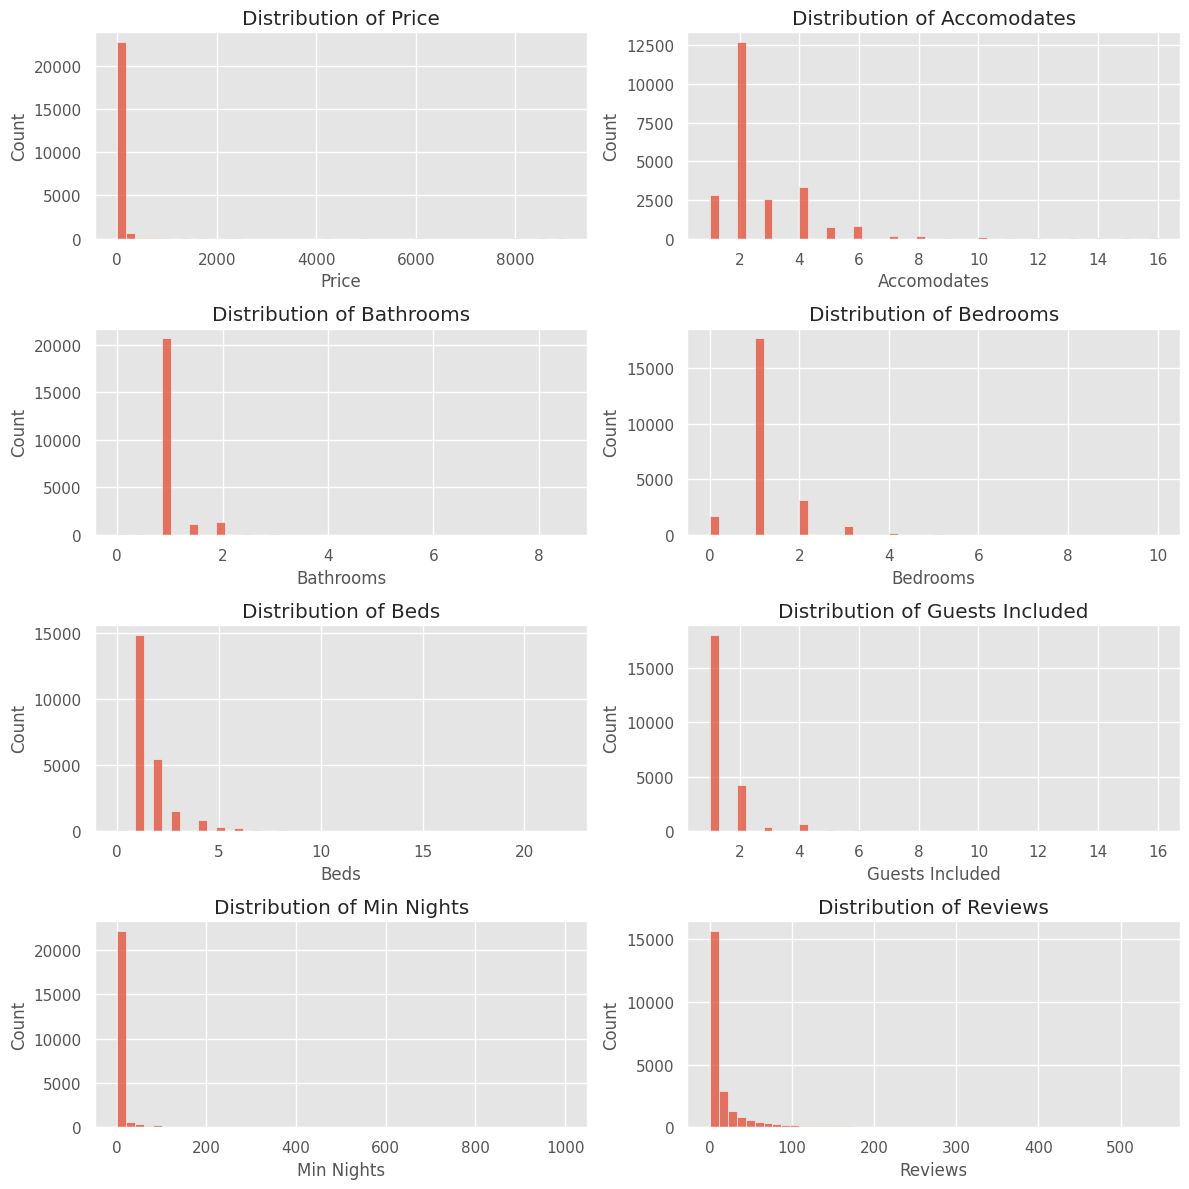

In [ ]:
# Checking the distribution of key numerical features
plot_histplot_for_columns(df, numerical_columns)

As expected, we can notice that some of the numerics are more categorical data like (for example, Accomadates, Bathrooms and Beds).
It worth using barplot to show relations ship with target value

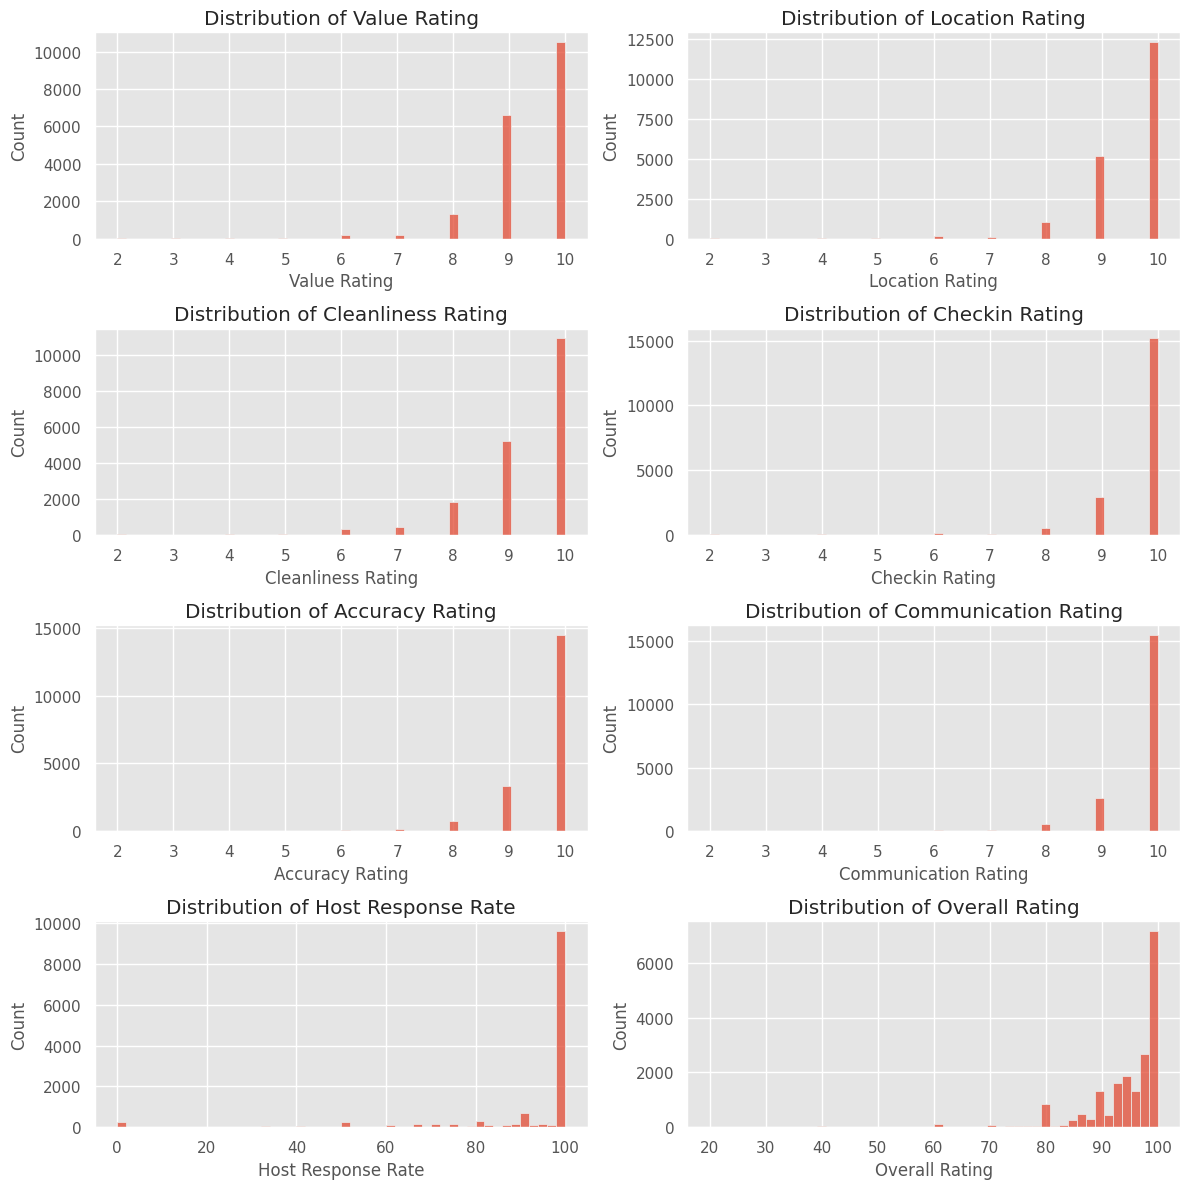

In [ ]:
plot_histplot_for_columns(df, rating_columns)

### Bars for continues numbers

In [ ]:
categorical_columns

['Room Type',
 'Property Type Reduced',
 'Neighborhood Group',
 'Postal Code Reduced',
 'Host Response Time']

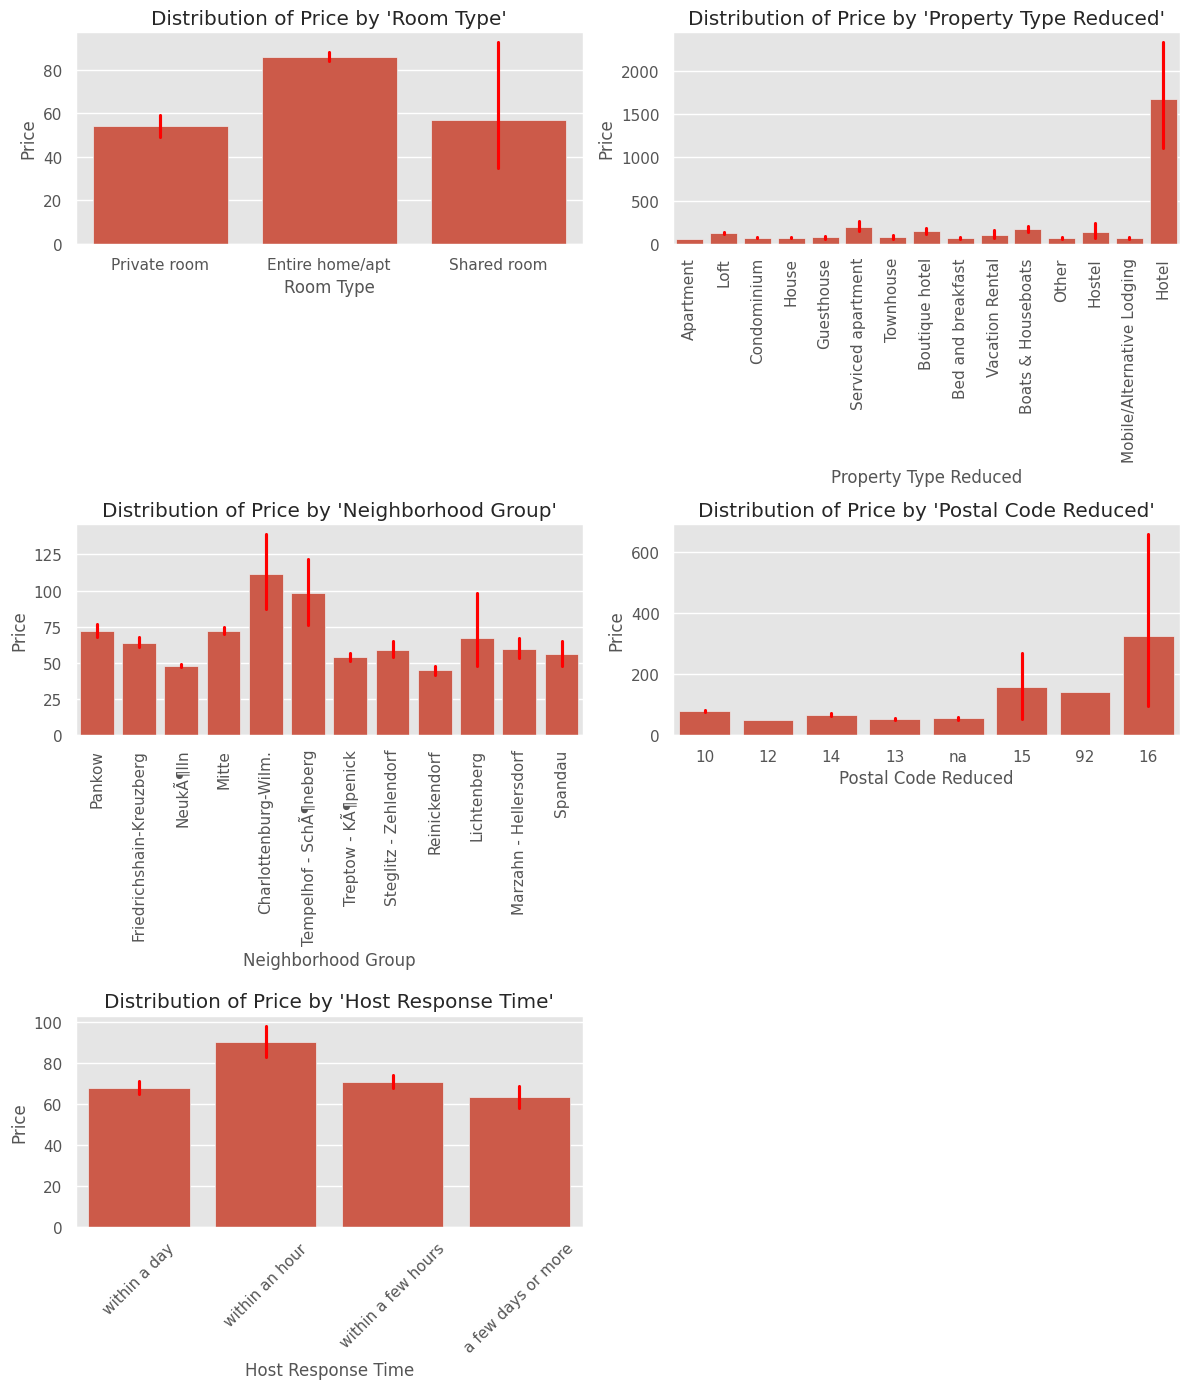

In [ ]:
xticks_map = {'Room Type':0, 'Property Type Reduced':90, 'Neighborhood Group':90, 'Postal Code Reduced':0, 'Host Response Time':45}
plt.figure(figsize=(12, 14))
plt.subplots_adjust(hspace = 0.5)
for i, col in enumerate(categorical_columns, 1):
  plt.subplot(3, 2, i)
  sns.barplot(x=df[col], y=df['Price'], errcolor="red")
  plt.xticks(rotation=xticks_map.get(col))
  plt.title(f"Distribution of Price by '{col}'")

plt.tight_layout()
plt.show()

In [ ]:
df['Room Type'].value_counts()

,count
Room Type,
Private room,11694
Entire home/apt,11528
Shared room,314


<Axes: xlabel='Price', ylabel='Count'>

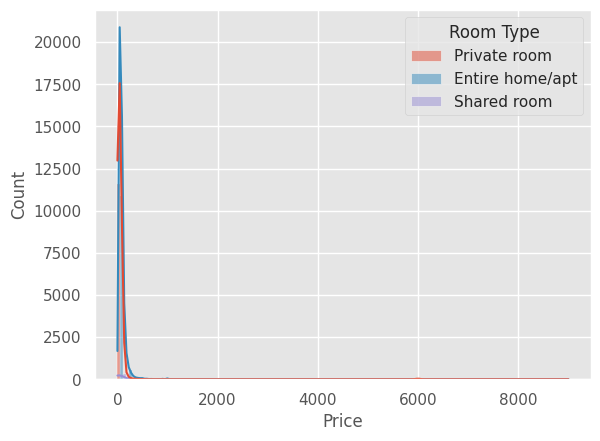

In [ ]:
# sns.histplot(data = df[df['Room Type'] == 'Private room'], x="Price", bins=50, kde=True)
sns.histplot(data = df, x="Price", bins=50, hue="Room Type", kde=True, multiple="dodge")

In [ ]:
boolean_columns

['Is Superhost', 'Is Exact Location', 'Instant Bookable']

<Axes: xlabel='Price', ylabel='Count'>

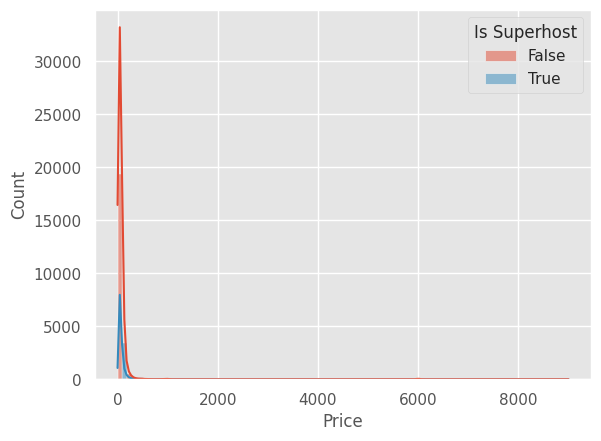

In [ ]:
sns.histplot(data = df, x="Price", bins=50, hue="Is Superhost", kde=True, multiple="dodge")

<Axes: xlabel='Price', ylabel='Count'>

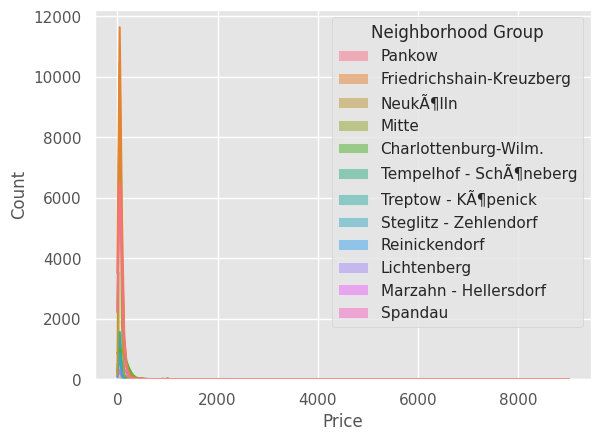

In [ ]:
sns.histplot(data = df, x="Price", bins=50, hue="Neighborhood Group", kde=True, multiple="dodge")

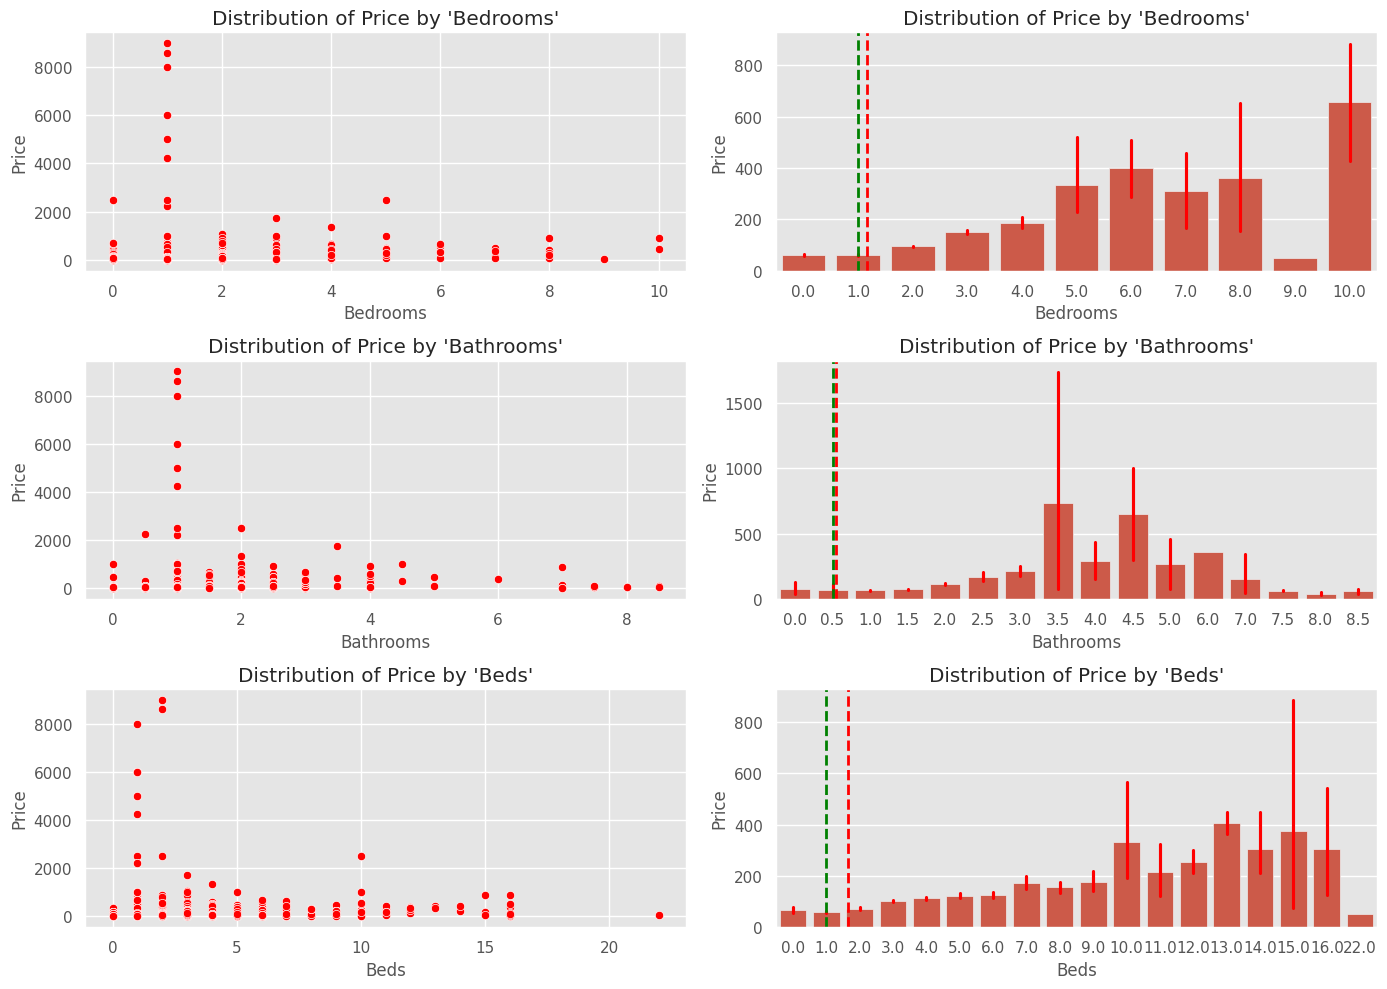

In [ ]:
bar_plot_columns = ['Bedrooms', 'Bathrooms', 'Beds']
plt.figure(figsize=(14, 10))
plt.subplots_adjust(hspace = 0.5)
i = 1
for col in bar_plot_columns:
  plt.subplot(3, 2, i)
  sns.scatterplot(x=df[col], y=df['Price'], color='red')
  plt.title(f"Distribution of Price by '{col}'")

  plt.subplot(3, 2, i+1)
  sns.barplot(x=df[col], y=df['Price'], errcolor="red")
  plt.title(f"Distribution of Price by '{col}'")
  plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2)
  plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2)

  i = i + 2
plt.tight_layout()
plt.show()

## Skewness

In [ ]:
def highlight(cell_value):
    highlight = 'background-color: mediumspringgreen;'
    default = ''
    negative = 'background-color: hotpink;'
    if cell_value > 1:
        return highlight
    elif cell_value < -1:
        return negative
    #else
       # return default

numericals = numerical_columns + rating_columns
pd.DataFrame(df[numericals].skew(),columns=['skewness']).sort_values(by='skewness', ascending=False).style.applymap(highlight)

,skewness
Price,26.846364
Min Nights,21.513526
Bathrooms,6.774987
Guests Included,5.123136
Reviews,4.350674
Beds,3.661029
Accomodates,2.652933
Bedrooms,2.235585
Cleanliness Rating,-2.478964
Location Rating,-2.601043


## Checking correlations among numerical features

In [ ]:
from sklearn.preprocessing import LabelEncoder

correlation_matrix_df = df.copy()
correlation_matrix_df['Host Since'] = pd.to_datetime(correlation_matrix_df['Host Since'])
correlation_matrix_df['Host Since Year'] = correlation_matrix_df['Host Since'].dt.year

# correlation_matrix_df = correlation_matrix_df.drop(columns=['Listing ID'], inplace=False)
correlation_matrix_df = correlation_matrix_df.select_dtypes(include=['number'])

le = LabelEncoder()
for col in categorical_columns:
  correlation_matrix_df[col] = le.fit_transform(df[col])

correlation_matrix = correlation_matrix_df.corr(method = 'spearman')
correlation_matrix

,Accuracy Rating,Bathrooms,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Latitude,Location Rating,Longitude,Overall Rating,Price,Square Feet,Value Rating,Accomodates,Bedrooms,Beds,Guests Included,Min Nights,Reviews,Host Since Year,Room Type,Property Type Reduced,Neighborhood Group,Postal Code Reduced,Host Response Time
Accuracy Rating,1.000000,0.007075,0.421621,0.438805,0.451931,0.067009,-0.010537,0.277569,0.007678,0.504771,0.012659,-0.046632,0.466987,-0.067989,-0.014801,-0.093856,-0.019311,0.051306,0.020411,-0.014312,0.002865,-0.016164,0.023474,0.004221,-0.021836
Bathrooms,0.007075,1.000000,0.012260,0.007116,0.012672,0.025218,0.002663,0.018613,-0.039814,0.026904,0.135117,0.237171,0.006142,0.159775,0.248755,0.184359,0.090454,0.034957,0.003102,-0.015596,-0.010268,0.110634,-0.005330,-0.020173,-0.030207
Checkin Rating,0.421621,0.012260,1.000000,0.314899,0.531120,0.073462,-0.024233,0.233883,0.003265,0.383310,0.014301,0.003069,0.346415,-0.040133,0.001099,-0.045305,-0.008052,0.017594,0.006095,-0.007194,0.020727,0.016780,0.023082,0.021840,-0.022730
Cleanliness Rating,0.438805,0.007116,0.314899,1.000000,0.335791,0.104619,0.005498,0.216864,-0.012798,0.536572,0.109540,-0.002138,0.414519,-0.025602,0.024437,-0.028780,0.019892,0.012673,0.030790,-0.019731,-0.044741,0.049168,0.032910,-0.006419,-0.061995
Communication Rating,0.451931,0.012672,0.531120,0.335791,1.000000,0.103146,-0.018931,0.254284,0.006258,0.429041,0.023975,-0.048749,0.370661,-0.045547,0.000935,-0.061720,-0.008054,0.032970,0.005549,-0.030640,0.003092,-0.012568,0.021865,0.011969,-0.025191
Host Response Rate,0.067009,0.025218,0.073462,0.104619,0.103146,1.000000,0.003129,0.011348,-0.010186,0.059906,0.058671,-0.055334,0.047919,0.049291,0.035790,0.038532,0.065488,0.002144,0.124039,-0.020892,-0.011463,0.037286,0.014748,0.001342,0.481033
Latitude,-0.010537,0.002663,-0.024233,0.005498,-0.018931,0.003129,1.000000,0.002327,-0.148875,-0.035761,0.058841,-0.009606,-0.028360,0.040139,0.005494,0.028869,0.028243,-0.006704,0.038171,0.022094,-0.041241,0.008725,-0.023114,-0.113718,-0.018161
Location Rating,0.277569,0.018613,0.233883,0.216864,0.254284,0.011348,0.002327,1.000000,-0.009260,0.312444,0.106923,0.109152,0.316290,-0.051518,-0.020789,-0.072014,-0.034511,0.032127,-0.012606,-0.012590,-0.007836,-0.051153,-0.080664,-0.232571,-0.067093
Longitude,0.007678,-0.039814,0.003265,-0.012798,0.006258,-0.010186,-0.148875,-0.009260,1.000000,0.031159,-0.053602,-0.160150,0.027408,-0.018334,-0.011354,-0.036356,0.003261,-0.011012,-0.029519,-0.045080,0.034804,-0.018948,-0.021919,-0.075183,0.051189
Overall Rating,0.504771,0.026904,0.383310,0.536572,0.429041,0.059906,-0.035761,0.312444,0.031159,1.000000,0.019397,0.041631,0.561708,-0.088859,0.002973,-0.095865,-0.065324,0.084265,-0.271822,0.022160,0.017398,-0.017091,0.018261,0.008375,0.031624


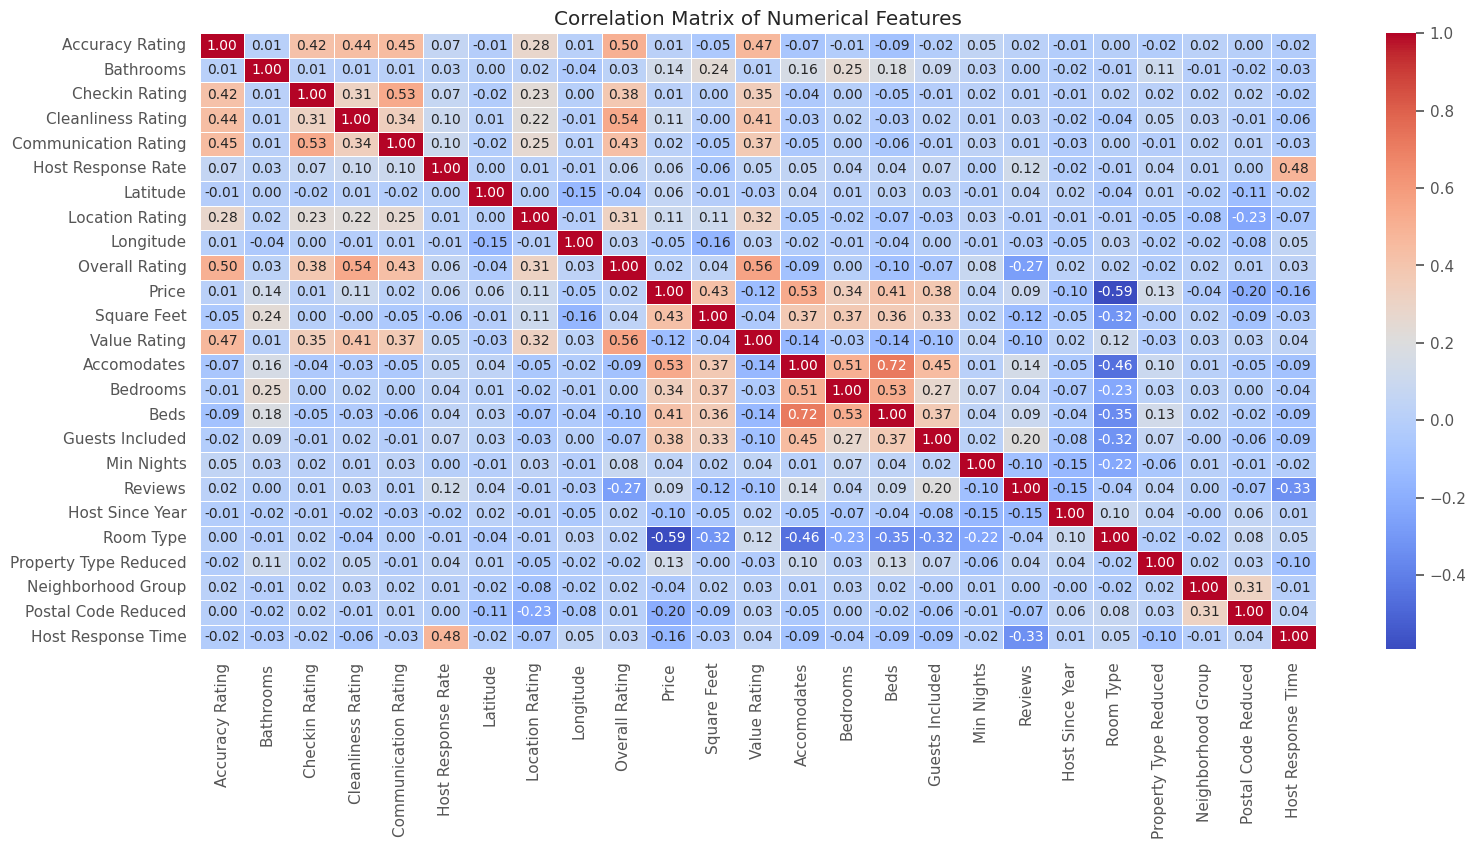

In [ ]:
plt.figure(figsize=(18, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, annot_kws={"size": 10})
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Outliers

In [ ]:
nonn_dummy = numerical_columns + rating_columns
df[nonn_dummy].describe().loc[['min', '25%', '50%', '75%', 'max']].T

,min,25%,50%,75%,max
Price,0.0,32.0,49.0,75.0,9000.0
Accomodates,1.0,2.0,2.0,3.0,16.0
Bathrooms,0.0,1.0,1.0,1.0,8.5
Bedrooms,0.0,1.0,1.0,1.0,10.0
Beds,0.0,1.0,1.0,2.0,22.0
Guests Included,1.0,1.0,1.0,1.0,16.0
Min Nights,1.0,2.0,3.0,4.0,1000.0
Reviews,0.0,1.0,5.0,17.0,545.0
Value Rating,2.0,9.0,10.0,10.0,10.0
Location Rating,2.0,9.0,10.0,10.0,10.0


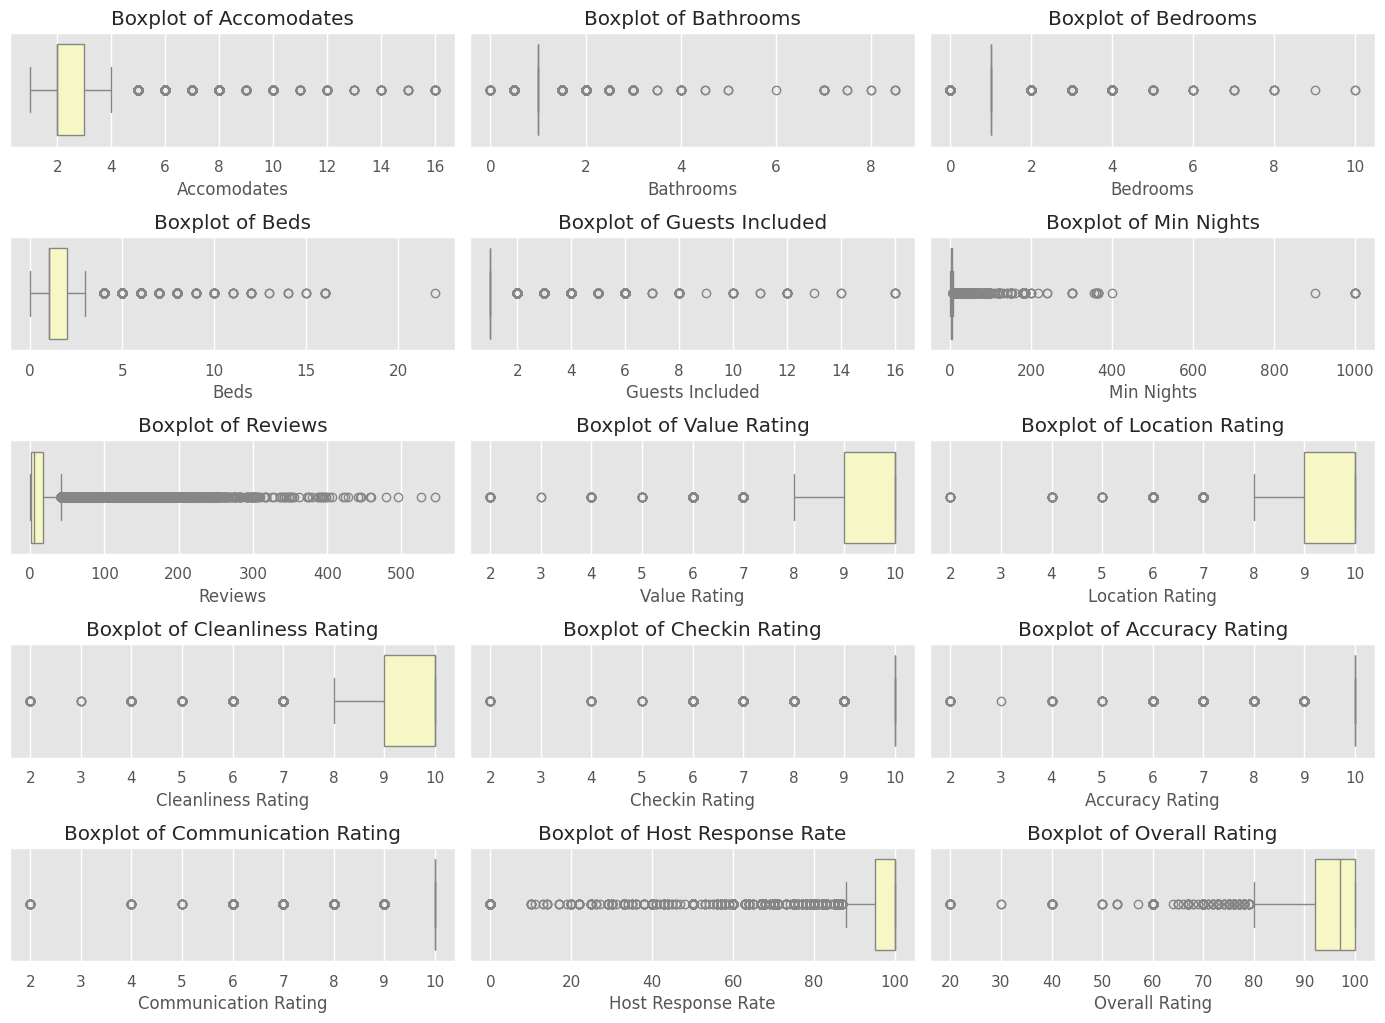

In [ ]:
# numericals = numerical_columns + ["Overall Rating", "Host Response Rate"]

plt.figure(figsize=(14, 20))
for i, col in enumerate([c for c in nonn_dummy if c != 'Price'], 1):
    plt.subplot(10, 3, i)
    sns.boxplot(x=df[col].dropna(), palette="Spectral")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Likely contains extreme values (high-end listings or pricing errors).
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

## Save state

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23536 entries, 0 to 23535
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        18888 non-null  float64
 1   Bathrooms              23507 non-null  float64
 2   Checkin Rating         18870 non-null  float64
 3   Cleanliness Rating     18892 non-null  float64
 4   Communication Rating   18886 non-null  float64
 5   Host Response Rate     13046 non-null  float64
 6   Latitude               23536 non-null  float64
 7   Location Rating        18871 non-null  float64
 8   Longitude              23536 non-null  float64
 9   Overall Rating         18914 non-null  float64
 10  Price                  23536 non-null  float64
 11  Square Feet            425 non-null    float64
 12  Value Rating           18868 non-null  float64
 13  review_date            19380 non-null  object 
 14  Comments               19378 non-null  object 
 15  Ho

In [ ]:
df.to_pickle("/content/drive/My Drive/Airbnb/df_EDA2.pkl")
df.to_csv("/content/drive/My Drive/Airbnb/df_EDA2.csv")

In [ ]:
# cleaned_df = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')
# cleaned_df.info()